---
title: MovieLens 100K Two-Tower Retrieval
category: Recommender Systems
tags:
  - recommender systems
  - two tower
  - retrieval
  - implicit feedback
  - movielens
  - pytorch
date: 2026-07-31
description: Train a small two-tower retrieval model on MovieLens 100K using implicit feedback derived from real ratings.
aliases:
  - /recc-sys/movielens-100k-two-tower-retrieval
sources:
  - https://files.grouplens.org/datasets/movielens/ml-100k-README.txt
  - https://files.grouplens.org/datasets/movielens/ml-100k/u.data
  - https://files.grouplens.org/datasets/movielens/ml-100k/u.item
  - https://www.tensorflow.org/recommenders/examples/basic_retrieval
---

## Goal

Build a small retrieval model on the real [MovieLens 100K data set](https://files.grouplens.org/datasets/movielens/ml-100k-README.txt). We will treat ratings of at least \(4\) as positive implicit feedback and train a two-tower model with sampled negatives.

The scoring function is the dot product

$$
s(u, i) = q_u^\\top k_i,
$$

where \(q_u\\) is the user embedding and \(k_i\\) is the item embedding. Retrieval quality will be measured with Recall@K and MRR@K on a held-out item per user.


In [1]:
## %pip install -q pandas numpy torch matplotlib

from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 7
np.random.seed(SEED)
_ = torch.manual_seed(SEED)


In [2]:
repo_root = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / ".git").exists()), Path.cwd())
root = repo_root / "work/notebook-data/movielens-100k"
root.mkdir(parents=True, exist_ok=True)

ratings_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
items_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.item"

ratings_path = root / "u.data"
items_path = root / "u.item"

for url, path in [(ratings_url, ratings_path), (items_url, items_path)]:
    if not path.exists():
        path.write_bytes(urlopen(url).read())

ratings = pd.read_csv(
    ratings_path,
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
    encoding="latin-1",
)

items = pd.read_csv(
    items_path,
    sep="|",
    header=None,
    encoding="latin-1",
    usecols=[0, 1],
    names=["item_id", "title"],
)

ratings = ratings.merge(items, on="item_id", how="left")
ratings.head()


,user_id,item_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [3]:
positives = ratings[ratings["rating"] >= 4].copy()
positives = positives.sort_values(["user_id", "timestamp"])

heldout = positives.groupby("user_id").tail(1)
train = positives.drop(index=heldout.index)

user_ids = sorted(positives["user_id"].unique())
item_ids = sorted(positives["item_id"].unique())
user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {i: j for j, i in enumerate(item_ids)}

train_user = torch.tensor(train["user_id"].map(user_to_idx).to_numpy(), dtype=torch.long)
train_item = torch.tensor(train["item_id"].map(item_to_idx).to_numpy(), dtype=torch.long)
test_pairs = list(
    zip(
        heldout["user_id"].map(user_to_idx).to_numpy(),
        heldout["item_id"].map(item_to_idx).to_numpy(),
    )
)

positives_by_user = {
    user_to_idx[u]: set(group["item_id"].map(item_to_idx).tolist())
    for u, group in positives.groupby("user_id")
}

num_users = len(user_ids)
num_items = len(item_ids)
print(f"train positives={len(train):,} heldout users={len(test_pairs):,}")


train positives=54,433 heldout users=942


In [4]:
class TwoTower(nn.Module):
    def __init__(self, num_users: int, num_items: int, dim: int = 64):
        super().__init__()
        self.user = nn.Embedding(num_users, dim)
        self.item = nn.Embedding(num_items, dim)
        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)

    def score(self, users, items):
        dot = (self.user(users) * self.item(items)).sum(dim=-1)
        bias = self.user_bias(users).squeeze(-1) + self.item_bias(items).squeeze(-1)
        return dot + bias


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TwoTower(num_users, num_items, dim=64).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

batch_size = 2048
steps = 2500
losses = []

train_user_device = train_user.to(device)
train_item_device = train_item.to(device)

for step in range(steps):
    idx = torch.randint(0, len(train_user_device), (batch_size,), device=device)
    u = train_user_device[idx]
    pos_i = train_item_device[idx]
    neg_i = torch.randint(0, num_items, (batch_size,), device=device)

    pos_score = model.score(u, pos_i)
    neg_score = model.score(u, neg_i)
    logits = torch.cat([pos_score, neg_score], dim=0)
    labels = torch.cat([torch.ones_like(pos_score), torch.zeros_like(neg_score)], dim=0)

    loss = F.binary_cross_entropy_with_logits(logits, labels)
    loss_value = loss.item()
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss_value)

    if step % 250 == 0:
        print(f"step={step:04d} loss={loss_value:.4f}")


step=0000 loss=3.2362


step=0250 loss=2.2360


step=0500 loss=1.4879


step=0750 loss=0.9925


step=1000 loss=0.7536


step=1250 loss=0.5870


step=1500 loss=0.5085


step=1750 loss=0.4019


step=2000 loss=0.3955


step=2250 loss=0.3531


In [6]:
def evaluate(model: TwoTower, test_pairs, positives_by_user, k: int = 10):
    user_emb = model.user.weight.detach()
    item_emb = model.item.weight.detach()
    user_bias = model.user_bias.weight.detach().squeeze(-1)
    item_bias = model.item_bias.weight.detach().squeeze(-1)

    recalls = []
    rr = []
    for u, target in test_pairs:
        scores = user_emb[u] @ item_emb.T + user_bias[u] + item_bias
        seen = positives_by_user[u] - {target}
        if seen:
            scores[list(seen)] = -1e9
        topk = scores.topk(k).indices.tolist()
        if target in topk:
            recalls.append(1.0)
            rr.append(1.0 / (topk.index(target) + 1))
        else:
            recalls.append(0.0)
            rr.append(0.0)
    return float(np.mean(recalls)), float(np.mean(rr))


recall_at_10, mrr_at_10 = evaluate(model.cpu(), test_pairs, positives_by_user, k=10)
print({"recall@10": recall_at_10, "mrr@10": mrr_at_10})


{'recall@10': 0.041401273885350316, 'mrr@10': 0.01159682202675833}


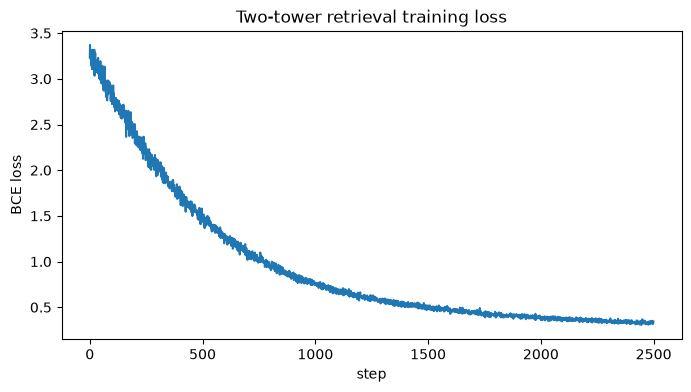

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Two-tower retrieval training loss")
plt.xlabel("step")
plt.ylabel("BCE loss")
plt.show()


In [8]:
title_to_item = {row.title: item_to_idx[row.item_id] for row in items.itertuples() if row.item_id in item_to_idx}
item_lookup = {item_to_idx[row.item_id]: row.title for row in items.itertuples() if row.item_id in item_to_idx}

anchor = "Star Wars (1977)"
anchor_idx = title_to_item[anchor]
anchor_vec = model.item.weight.detach()[anchor_idx]
sims = model.item.weight.detach() @ anchor_vec
top = sims.topk(10).indices.tolist()
[item_lookup[i] for i in top]


['Star Wars (1977)',
 'Return of the Jedi (1983)',
 'War, The (1994)',
 'Alien (1979)',
 'Miracle on 34th Street (1994)',
 'Rosencrantz and Guildenstern Are Dead (1990)',
 'Happy Gilmore (1996)',
 'Prophecy II, The (1998)',
 'Mother (1996)',
 'Delicatessen (1991)']

## Where To Push Next

This notebook is the retrieval stage only. Good follow-ons:

1. Add side features from `u.user` and genre indicators from `u.item`.
2. Replace pointwise BCE with BPR or sampled softmax.
3. Add a reranker and compare Recall@K against NDCG@K.
